In [1]:
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
from imblearn.over_sampling import RandomOverSampler
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.utils.validation import check_is_fitted
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
# Framingham Heart Study dataset, commonly used for cardiovascular disease risk prediction. It typically includes demographics, behavioral factors, clinical measurements, and a binary target (10-year CHD risk).
df = pd.read_csv("framingham.csv")

In [3]:
df.head(10)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,2.0,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,0,63,1.0,0,0.0,0.0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1
7,0,45,2.0,1,20.0,0.0,0,0,0,313.0,100.0,71.0,21.68,79.0,78.0,0
8,1,52,1.0,0,0.0,0.0,0,1,0,260.0,141.5,89.0,26.36,76.0,79.0,0
9,1,43,1.0,1,30.0,0.0,0,1,0,225.0,162.0,107.0,23.61,93.0,88.0,0


In [5]:
df.shape

(4240, 16)

In [6]:
df.isnull().sum()

,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


In [7]:
x = df.drop(columns = "TenYearCHD")
y = df.TenYearCHD

# Splitting the dataset into Training data and Testing Data in the ratio 8:2.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

# Splitting the Training data further into Training data and Validation Data in the ratio 8:2.
# So, final ratios are: Training Data -> 80% of 80%  = 64 %, Testing Data = 20 %, Validation Data -> 20% of 80% = 16 %.
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.2, random_state = 42, stratify = y_train)

In [8]:
model = make_pipeline(
    SimpleImputer(strategy="median"),
    DecisionTreeClassifier(
        max_depth=25,
        random_state=42
    )
)

model.fit(x_train, y_train)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(max_depth=25, random_state=42))])

In [9]:
model.score(x_val, y_val)

0.7687776141384389

In [10]:
model.score(x_train, y_train)

1.0

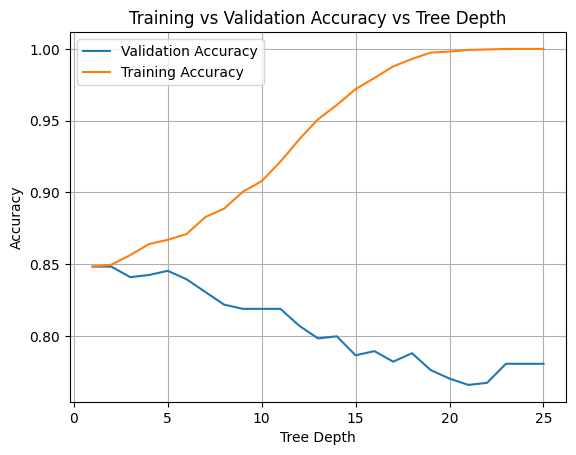

In [11]:
Val_acc = []
Train_acc = []

for d in range(1, 26):
  model = make_pipeline(SimpleImputer(), DecisionTreeClassifier(max_depth=d,random_state=42))
  model.fit(x_train, y_train)
  Val_acc.append(model.score(x_val, y_val))
  Train_acc.append(model.score(x_train, y_train))

#Now plot both lists
plt.plot(range(1, 26), Val_acc, label = "Validation Accuracy")
plt.plot(range(1, 26), Train_acc, label = "Training Accuracy")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy vs Tree Depth")
plt.grid()
plt.legend()

In [12]:
# Oversample ONLY training
# Oversampling is a data preprocessing technique used to address class imbalance, where one class (majority) heavily outnumbers another (minority),
# often in tasks like fraud detection or medical diagnosis.

over_sampler = RandomOverSampler(random_state=42)
x_train_over, y_train_over = over_sampler.fit_resample(x_train, y_train)

print("Original train shape:", x_train.shape)
print("Oversampled train shape:", x_train_over.shape)

Original train shape: (2713, 15)
Oversampled train shape: (4602, 15)


In [13]:
model2 = make_pipeline(SimpleImputer(), RandomForestClassifier())
print(model2)

Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('randomforestclassifier', RandomForestClassifier())])


In [14]:
# K Cross Validation
cv_acc_scores = cross_val_score(model2, x_train_over, y_train_over, cv = 5, n_jobs=-1)
print(cv_acc_scores)
print("Mean CV Accuracy:", cv_acc_scores.mean())

[0.9771987  0.96742671 0.97391304 0.98043478 0.97934783]
Mean CV Accuracy: 0.9756642118680074


In [15]:
params = {
    "simpleimputer__strategy": ["mean", "median"],
    "randomforestclassifier__n_estimators": [10, 100],
    "randomforestclassifier__max_depth": [2, 10, 30]
}

In [16]:
#We'll use Grid Search CV(Cross Valuation) to calculate every possible pramaeter combination

model_main = GridSearchCV(
    model2,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring="roc_auc"
)

In [17]:
model_main.fit(x_train_over, y_train_over)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('simpleimputer', SimpleImputer()),
                                       ('randomforestclassifier',
                                        RandomForestClassifier())]),
             n_jobs=-1,
             param_grid={'randomforestclassifier__max_depth': [2, 10, 30],
                         'randomforestclassifier__n_estimators': [10, 100],
                         'simpleimputer__strategy': ['mean', 'median']},
             scoring='roc_auc', verbose=1)

In [18]:
cv_results = pd.DataFrame(model_main.cv_results_)
cv_results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_randomforestclassifier__max_depth,param_randomforestclassifier__n_estimators,param_simpleimputer__strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.092241,0.008618,0.015923,0.004851,2,10,mean,"{'randomforestclassifier__max_depth': 2, 'rand...",0.735143,0.727931,0.722259,0.740305,0.696779,0.724483,0.015155,11
1,0.079245,0.014875,0.017590,0.003223,2,10,median,"{'randomforestclassifier__max_depth': 2, 'rand...",0.737296,0.708153,0.724690,0.722904,0.697793,0.718167,0.013757,12
2,0.721147,0.046802,0.038847,0.009533,2,100,mean,"{'randomforestclassifier__max_depth': 2, 'rand...",0.752841,0.725361,0.735414,0.739948,0.704707,0.731654,0.016109,9
3,0.490637,0.098917,0.025299,0.003039,2,100,median,"{'randomforestclassifier__max_depth': 2, 'rand...",0.743853,0.721072,0.739719,0.736798,0.715617,0.731412,0.011038,10
4,0.081934,0.001235,0.010467,0.000300,10,10,mean,"{'randomforestclassifier__max_depth': 10, 'ran...",0.955899,0.959295,0.946890,0.967481,0.964844,0.958882,0.007244,7
5,0.093485,0.009566,0.010410,0.000331,10,10,median,"{'randomforestclassifier__max_depth': 10, 'ran...",0.942622,0.946680,0.945482,0.954863,0.954041,0.948738,0.004855,8
6,0.736085,0.015868,0.034933,0.001484,10,100,mean,"{'randomforestclassifier__max_depth': 10, 'ran...",0.965453,0.974352,0.967495,0.983053,0.973776,0.972826,0.006174,5
7,0.742342,0.008438,0.034727,0.005043,10,100,median,"{'randomforestclassifier__max_depth': 10, 'ran...",0.968099,0.970895,0.970723,0.981484,0.972235,0.972687,0.004598,6
8,0.099365,0.002618,0.010703,0.000278,30,10,mean,"{'randomforestclassifier__max_depth': 30, 'ran...",0.989753,0.996586,0.999464,0.999449,0.998400,0.996730,0.003643,3
9,0.105393,0.002584,0.010790,0.000084,30,10,median,"{'randomforestclassifier__max_depth': 30, 'ran...",0.988006,0.998828,0.998254,0.999338,0.998036,0.996492,0.004268,4


In [19]:
best_model = model_main.best_estimator_

test_score = best_model.score(x_test, y_test)
print("Test Score:", test_score)

Test Score: 0.8313679245283019


In [ ]:
male = widgets.IntText(description="Male (0/1):")
age = widgets.IntText(description="Age:")
education = widgets.FloatText(description="Education:")
currentSmoker = widgets.IntText(description="Smoker (0/1):")
cigsPerDay = widgets.FloatText(description="Cigs/Day:")
BPMeds = widgets.IntText(description="BP Meds (0/1):")
prevalentStroke = widgets.IntText(description="Stroke (0/1):")
prevalentHyp = widgets.IntText(description="Hypertension (0/1):")
diabetes = widgets.IntText(description="Diabetes (0/1):")
totChol = widgets.FloatText(description="Cholesterol:")
sysBP = widgets.FloatText(description="Sys BP:")
diaBP = widgets.FloatText(description="Dia BP:")
BMI = widgets.FloatText(description="BMI:")
heartRate = widgets.FloatText(description="Heart Rate:")
glucose = widgets.FloatText(description="Glucose:")

predict_btn = widgets.Button(description="Predict CHD Risk")
output = widgets.Output()

In [21]:
def predict_chd(b):
    with output:
        output.clear_output()

        data = pd.DataFrame([{
            "male": male.value,
            "age": age.value,
            "education": education.value,
            "currentSmoker": currentSmoker.value,
            "cigsPerDay": cigsPerDay.value,
            "BPMeds": BPMeds.value,
            "prevalentStroke": prevalentStroke.value,
            "prevalentHyp": prevalentHyp.value,
            "diabetes": diabetes.value,
            "totChol": totChol.value,
            "sysBP": sysBP.value,
            "diaBP": diaBP.value,
            "BMI": BMI.value,
            "heartRate": heartRate.value,
            "glucose": glucose.value
        }])

        pred = best_model.predict(data)[0]

        if pred == 1:
            print("⚠ High Risk of CHD")
        else:
            print("✅ Low Risk of CHD")

In [22]:
predict_btn.on_click(predict_chd)

In [23]:
display(
    male, age, education, currentSmoker, cigsPerDay,
    BPMeds, prevalentStroke, prevalentHyp, diabetes,
    totChol, sysBP, diaBP, BMI, heartRate, glucose,
    predict_btn, output
)

IntText(value=0, description='Male (0/1):')

IntText(value=0, description='Age:')

FloatText(value=0.0, description='Education:')

IntText(value=0, description='Smoker (0/1):')

FloatText(value=0.0, description='Cigs/Day:')

...

FloatText(value=0.0, description='BMI:')

FloatText(value=0.0, description='Heart Rate:')

FloatText(value=0.0, description='Glucose:')

Button(description='Predict CHD Risk', style=ButtonStyle())

Output()